# Task 1: Anomaly Detection (IQR + Isolation Forest)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("images", exist_ok=True)
rng = np.random.default_rng(42)

# 2000 hourly readings from a machine with 3 sensors
n = 2000
t = np.arange(n)
temperature = 50 + 5 * np.sin(2 * np.pi * t / 24) + rng.normal(0, 1, n)       # daily cycle
vibration = 0.5 + 0.1 * (temperature - 50) / 5 + rng.normal(0, 0.05, n)       # tied to temperature
power = 200 + 4 * (temperature - 50) + rng.normal(0, 5, n)                    # tied to temperature

df = pd.DataFrame({"time": t, "temperature": temperature,
                   "vibration": vibration, "power": power})
df["is_anomaly"] = 0
df["anomaly_type"] = "normal"

# Type 1: sudden temperature spikes or drops
spike_idx = rng.choice(n, 40, replace=False)
df.loc[spike_idx, "temperature"] += rng.choice([-1, 1], 40) * rng.uniform(15, 25, 40)
df.loc[spike_idx, ["is_anomaly", "anomaly_type"]] = [1, "spike"]

# Type 2: contextual anomalies - vibration is normal-looking alone,
# but wrong for a hot machine (only visible when sensors are viewed together)
hot = np.setdiff1d(np.where(temperature > 53)[0], spike_idx)
ctx_idx = rng.choice(hot, 30, replace=False)
df.loc[ctx_idx, "vibration"] = 0.40
df.loc[ctx_idx, ["is_anomaly", "anomaly_type"]] = [1, "contextual"]

# Type 3: sensor faults - power reading collapses
rest = np.setdiff1d(np.arange(n), np.concatenate([spike_idx, ctx_idx]))
fault_idx = rng.choice(rest, 30, replace=False)
df.loc[fault_idx, "power"] = rng.uniform(0, 20, 30)
df.loc[fault_idx, ["is_anomaly", "anomaly_type"]] = [1, "fault"]

df.to_csv("sensor_data.csv", index=False)
print(df.shape)
print(df["anomaly_type"].value_counts())
df.head()

(2000, 6)
anomaly_type
normal        1900
spike           40
fault           30
contextual      30
Name: count, dtype: int64


,time,temperature,vibration,power,is_anomaly,anomaly_type
0,0,50.304717,0.483497,202.484891,0,normal
1,1,50.254111,0.471788,205.492536,0,normal
2,2,53.250451,0.586710,214.368411,0,normal
3,3,54.476099,0.602115,229.098553,0,normal
4,4,52.379092,0.477342,216.665305,0,normal


       temperature  vibration    power
count      2000.00    2000.00  2000.00
mean         49.91       0.50   197.13
std           4.54       0.09    27.60
min          26.28       0.25     1.78
25%          46.51       0.43   186.38
50%          49.83       0.50   199.41
75%          53.35       0.57   212.78
max          78.07       0.74   243.36


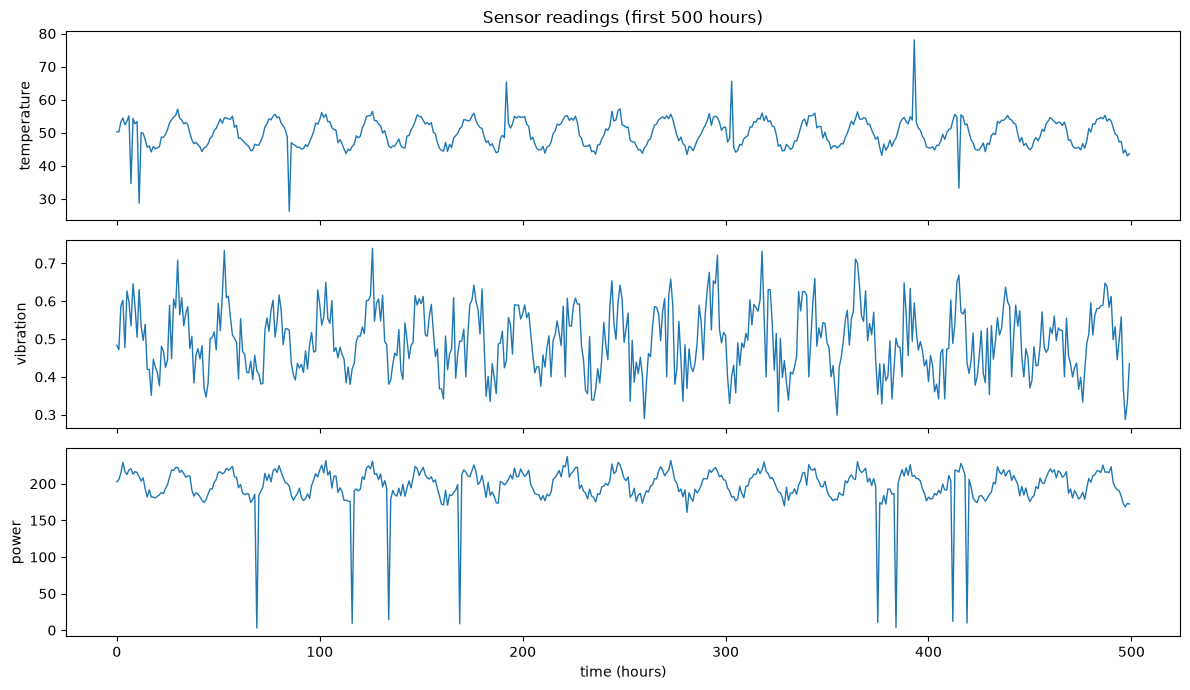

In [2]:
print(df[["temperature", "vibration", "power"]].describe().round(2))

sub = df.iloc[:500]
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, f in zip(axes, ["temperature", "vibration", "power"]):
    ax.plot(sub["time"], sub[f], lw=1)
    ax.set_ylabel(f)
axes[0].set_title("Sensor readings (first 500 hours)")
axes[-1].set_xlabel("time (hours)")
plt.tight_layout()
plt.savefig("images/sensor_overview.png", dpi=150, bbox_inches="tight")
plt.show()

Flagged per feature:
temperature    36
vibration       0
power          30
dtype: int64
Total flagged by IQR: 66


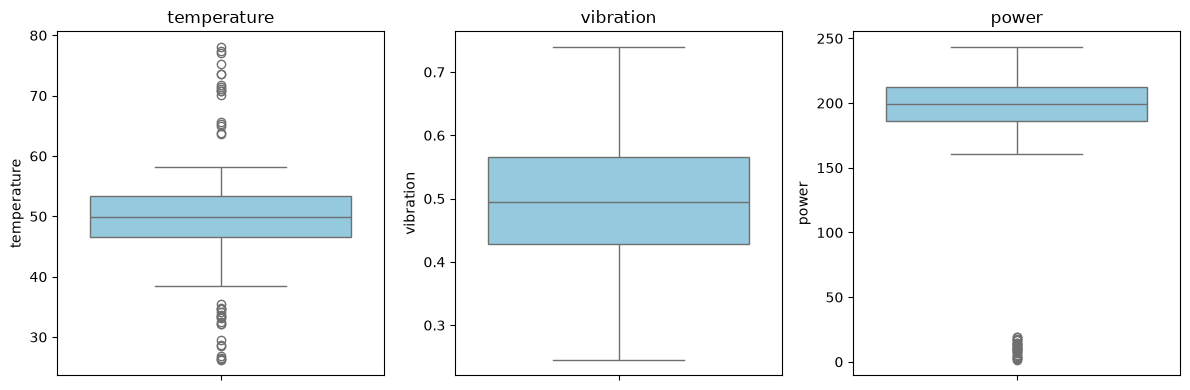

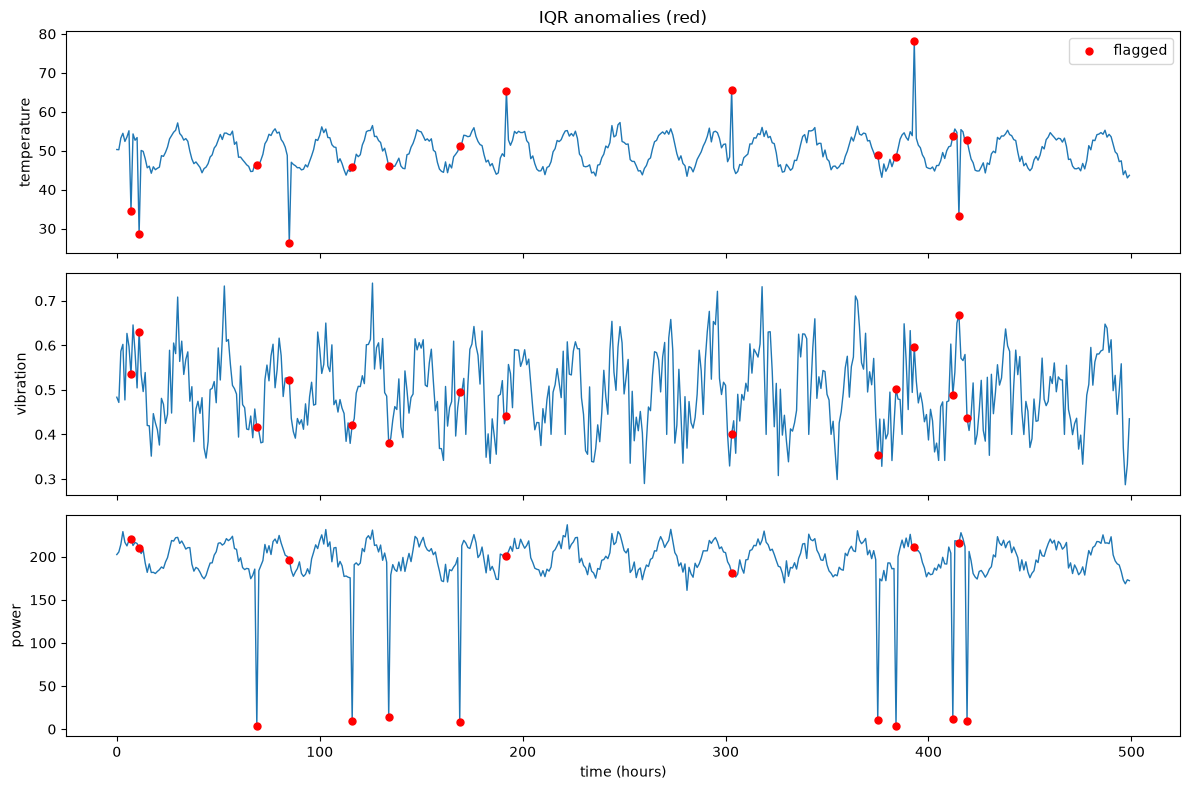

In [3]:
features = ["temperature", "vibration", "power"]

def iqr_flags(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

iqr_df = pd.DataFrame({f: iqr_flags(df[f]) for f in features})
df["iqr_anomaly"] = iqr_df.any(axis=1).astype(int)

print("Flagged per feature:")
print(iqr_df.sum())
print("Total flagged by IQR:", df["iqr_anomaly"].sum())

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, f in zip(axes, features):
    sns.boxplot(y=df[f], ax=ax, color="skyblue")
    ax.set_title(f)
plt.tight_layout()
plt.savefig("images/iqr_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Reusable plot: flagged points in red on each sensor
def plot_flags(flag_col, title, filename, n_points=500):
    sub = df.iloc[:n_points]
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, f in zip(axes, features):
        ax.plot(sub["time"], sub[f], lw=1)
        hit = sub[sub[flag_col] == 1]
        ax.scatter(hit["time"], hit[f], color="red", s=25, zorder=3, label="flagged")
        ax.set_ylabel(f)
    axes[0].set_title(title)
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("time (hours)")
    plt.tight_layout()
    plt.savefig(f"images/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

plot_flags("iqr_anomaly", "IQR anomalies (red)", "iqr_anomalies.png")

Total flagged by Isolation Forest: 100


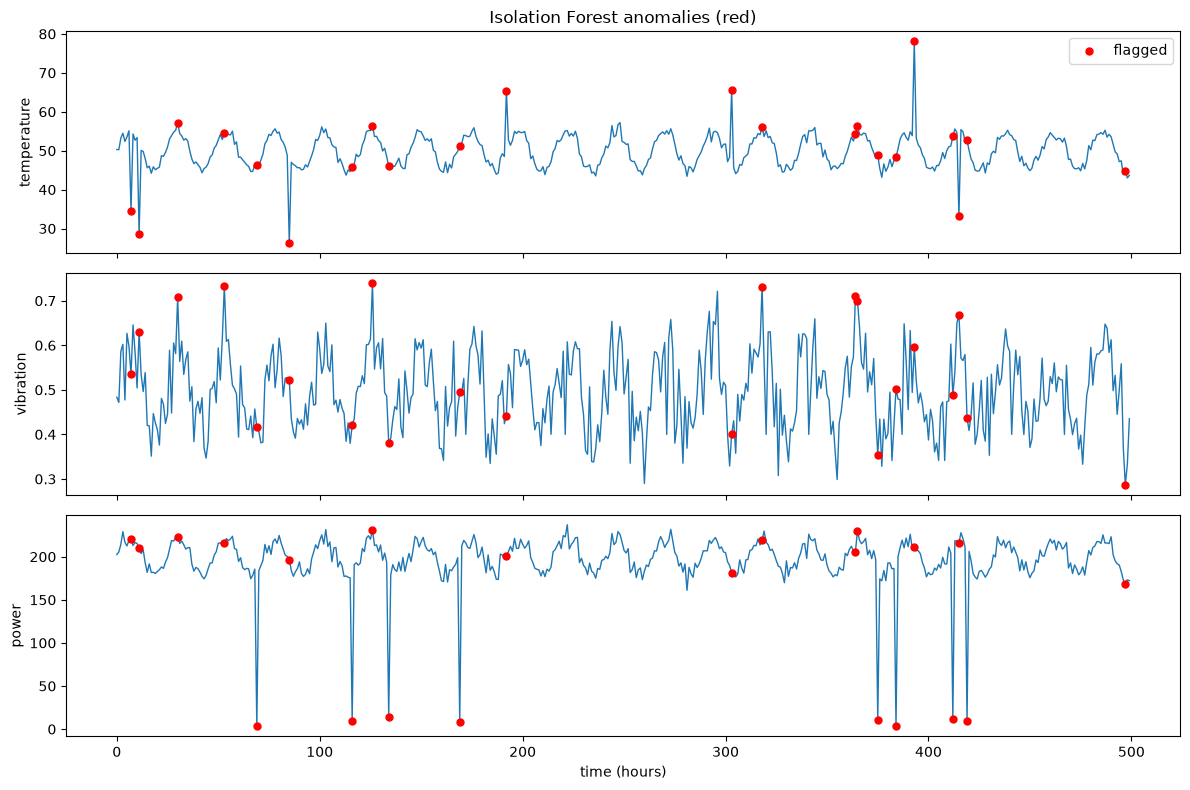

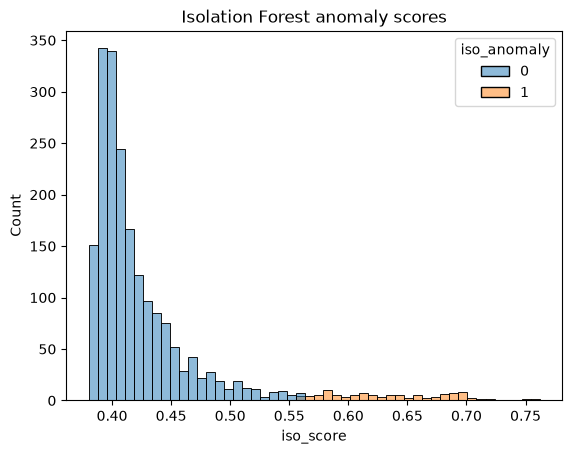

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df[features])

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df["iso_anomaly"] = (iso.fit_predict(X) == -1).astype(int)
df["iso_score"] = -iso.score_samples(X)     # higher = more anomalous

print("Total flagged by Isolation Forest:", df["iso_anomaly"].sum())

plot_flags("iso_anomaly", "Isolation Forest anomalies (red)", "isolation_forest_anomalies.png")

sns.histplot(data=df, x="iso_score", hue="iso_anomaly", bins=50)
plt.title("Isolation Forest anomaly scores")
plt.savefig("images/iso_scores.png", dpi=150, bbox_inches="tight")
plt.show()

             Method  Flagged  Precision  Recall     F1
0               IQR       66       1.00    0.66  0.795
1  Isolation Forest      100       0.73    0.73  0.730

Share of each anomaly type caught:
              iqr_anomaly  iso_anomaly
anomaly_type                          
contextual            0.0          0.1
fault                 1.0          1.0
spike                 0.9          1.0


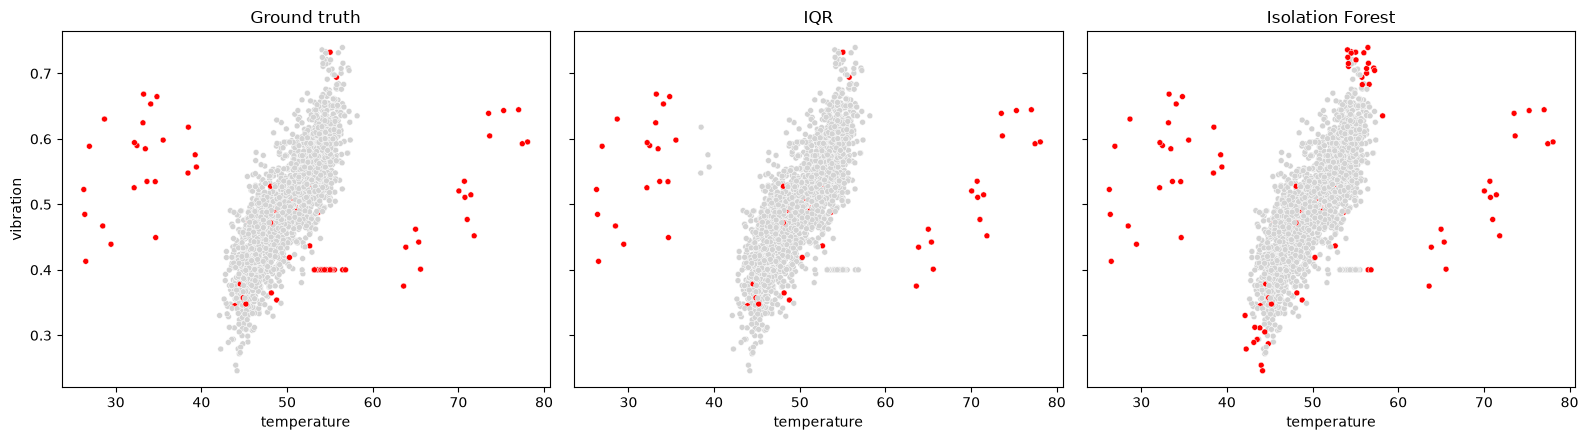

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, col in [("IQR", "iqr_anomaly"), ("Isolation Forest", "iso_anomaly")]:
    rows.append({
        "Method": name,
        "Flagged": int(df[col].sum()),
        "Precision": precision_score(df["is_anomaly"], df[col]),
        "Recall": recall_score(df["is_anomaly"], df[col]),
        "F1": f1_score(df["is_anomaly"], df[col]),
    })
results = pd.DataFrame(rows).round(3)
print(results)

# Which TYPES of anomaly did each method catch?
by_type = (df[df["is_anomaly"] == 1]
           .groupby("anomaly_type")[["iqr_anomaly", "iso_anomaly"]].mean().round(2))
print("\nShare of each anomaly type caught:")
print(by_type)

# Side-by-side scatter: truth vs IQR vs Isolation Forest
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
panels = [("is_anomaly", "Ground truth"), ("iqr_anomaly", "IQR"), ("iso_anomaly", "Isolation Forest")]
for ax, (col, name) in zip(axes, panels):
    sns.scatterplot(data=df, x="temperature", y="vibration", hue=col,
                    palette={0: "lightgrey", 1: "red"}, s=18, ax=ax, legend=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("images/comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
n_true = int(df["is_anomaly"].sum())
res_rows = "\n".join(
    f"| {r.Method} | {r.Flagged} | {r.Precision:.3f} | {r.Recall:.3f} | {r.F1:.3f} |"
    for r in results.itertuples())
type_rows = "\n".join(
    f"| {t} | {r.iqr_anomaly:.0%} | {r.iso_anomaly:.0%} |" for t, r in by_type.iterrows())
ctx_iqr, ctx_iso = by_type.loc["contextual", "iqr_anomaly"], by_type.loc["contextual", "iso_anomaly"]
spk_iqr, spk_iso = by_type.loc["spike", "iqr_anomaly"], by_type.loc["spike", "iso_anomaly"]

readme = f"""# Task 1: Anomaly Detection (IQR + Isolation Forest)

## Overview
This project detects anomalies in IoT sensor readings using two approaches: a statistical method (IQR rule) and an unsupervised machine learning method (Isolation Forest). The two are compared on precision, recall and F1.

## Dataset
A synthetic dataset of {len(df)} hourly readings from a machine with three sensors (temperature, vibration, power), saved as `sensor_data.csv`. Temperature follows a daily cycle and the other two sensors depend on it. I injected {n_true} anomalies ({n_true/len(df):.1%}) of three kinds:
- **spike**: sudden temperature jump or drop
- **contextual**: vibration looks normal alone but is wrong for the current temperature
- **fault**: power reading collapses

The labels are used **only for evaluation**. Neither method sees them.

![Sensor overview](images/sensor_overview.png)

## Methods
**1. IQR rule.** A value is flagged if it lies outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. It is applied to each sensor separately, and a reading is flagged if any sensor is an outlier.

![IQR boxplots](images/iqr_boxplots.png)
![IQR anomalies](images/iqr_anomalies.png)

**2. Isolation Forest.** Features are standardised, then 200 random trees isolate the data. Anomalies need fewer splits to be isolated, which gives them a higher anomaly score. `contamination=0.05`, `random_state=42`.

![Isolation Forest anomalies](images/isolation_forest_anomalies.png)
![Anomaly scores](images/iso_scores.png)

## Results
| Method | Flagged | Precision | Recall | F1 |
|---|---|---|---|---|
{res_rows}

Share of each anomaly type caught:

| Anomaly type | IQR | Isolation Forest |
|---|---|---|
{type_rows}

![Comparison](images/comparison.png)

## Interpretation
- IQR caught {spk_iqr:.0%} of spikes but only {ctx_iqr:.0%} of contextual anomalies. It checks one sensor at a time, so a reading that is normal on its own but wrong in combination goes unnoticed.
- Isolation Forest caught {spk_iso:.0%} of spikes and {ctx_iso:.0%} of contextual anomalies because it considers all sensors together.
- IQR is simple, fast and explainable, but assumes a fixed range per feature. Isolation Forest handles relationships between features but needs the contamination rate and is harder to explain.

## How to Run
```bash
pip install -r requirements.txt
jupyter notebook anomaly_detection.ipynb
```
Run all cells from top to bottom. The notebook generates `sensor_data.csv` and the images.

## Limitations and Future Work
- The data is synthetic, and real data is messier. Next step: apply the same methods to a real dataset such as the Numenta Anomaly Benchmark.
- `contamination=0.05` matches the injected rate. In real use the rate is unknown and must be estimated or tuned.
- The IQR rule ignores the daily cycle. A rolling-window IQR or seasonal decomposition would catch more.
- Other methods to try: Local Outlier Factor, One-Class SVM, DBSCAN.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)
print(readme)

# Task 1: Anomaly Detection (IQR + Isolation Forest)

## Overview
This project detects anomalies in IoT sensor readings using two approaches: a statistical method (IQR rule) and an unsupervised machine learning method (Isolation Forest). The two are compared on precision, recall and F1.

## Dataset
A synthetic dataset of 2000 hourly readings from a machine with three sensors (temperature, vibration, power), saved as `sensor_data.csv`. Temperature follows a daily cycle and the other two sensors depend on it. I injected 100 anomalies (5.0%) of three kinds:
- **spike**: sudden temperature jump or drop
- **contextual**: vibration looks normal alone but is wrong for the current temperature
- **fault**: power reading collapses

The labels are used **only for evaluation**. Neither method sees them.

![Sensor overview](images/sensor_overview.png)

## Methods
**1. IQR rule.** A value is flagged if it lies outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. It is applied to each sensor separately, and a rea